Loading TransUNet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz
load_pretrained: grid-size from 14 to 16
Loading TransUNet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz
load_pretrained: grid-size from 14 to 16

#################################################################
  Evaluating seed 22
#################################################################

── Sanity Check ──────────────────────────────────────────────
Loaded 7473 samples from /home/ahsan/test-project/ISIC-2019/ISIC_Metadata/test_metadata_size_shortcut.csv
  Benign    (bm=0): 5830
  Malignant (bm=1): 1643
  No Patches      : 3783
  Patches         : 3690
Mask classes found (first 200 samples): [0, 1]
  *** WARNING: class 2 still missing — check mask_interpolation and seg_mask dtype ***
  Sample batch dice: 0.8594  (should be in [0,

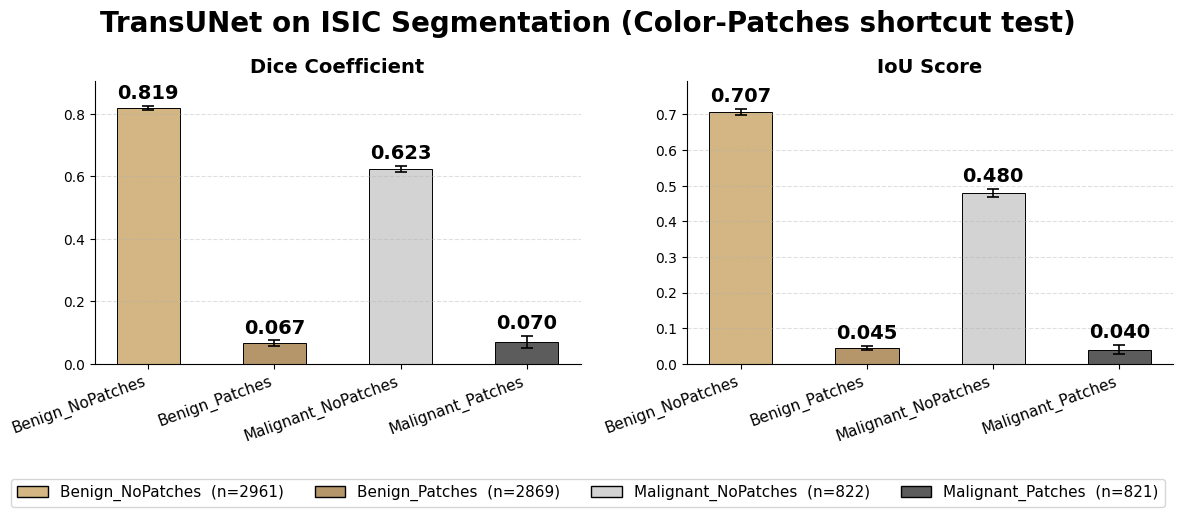

Plot saved → isic_test_id_results.png
Loaded 7473 samples from /home/ahsan/test-project/ISIC-2019/ISIC_Metadata/test_metadata_size_shortcut.csv
  Benign    (bm=0): 5830
  Malignant (bm=1): 1643
  No Patches      : 3783
  Patches         : 3690


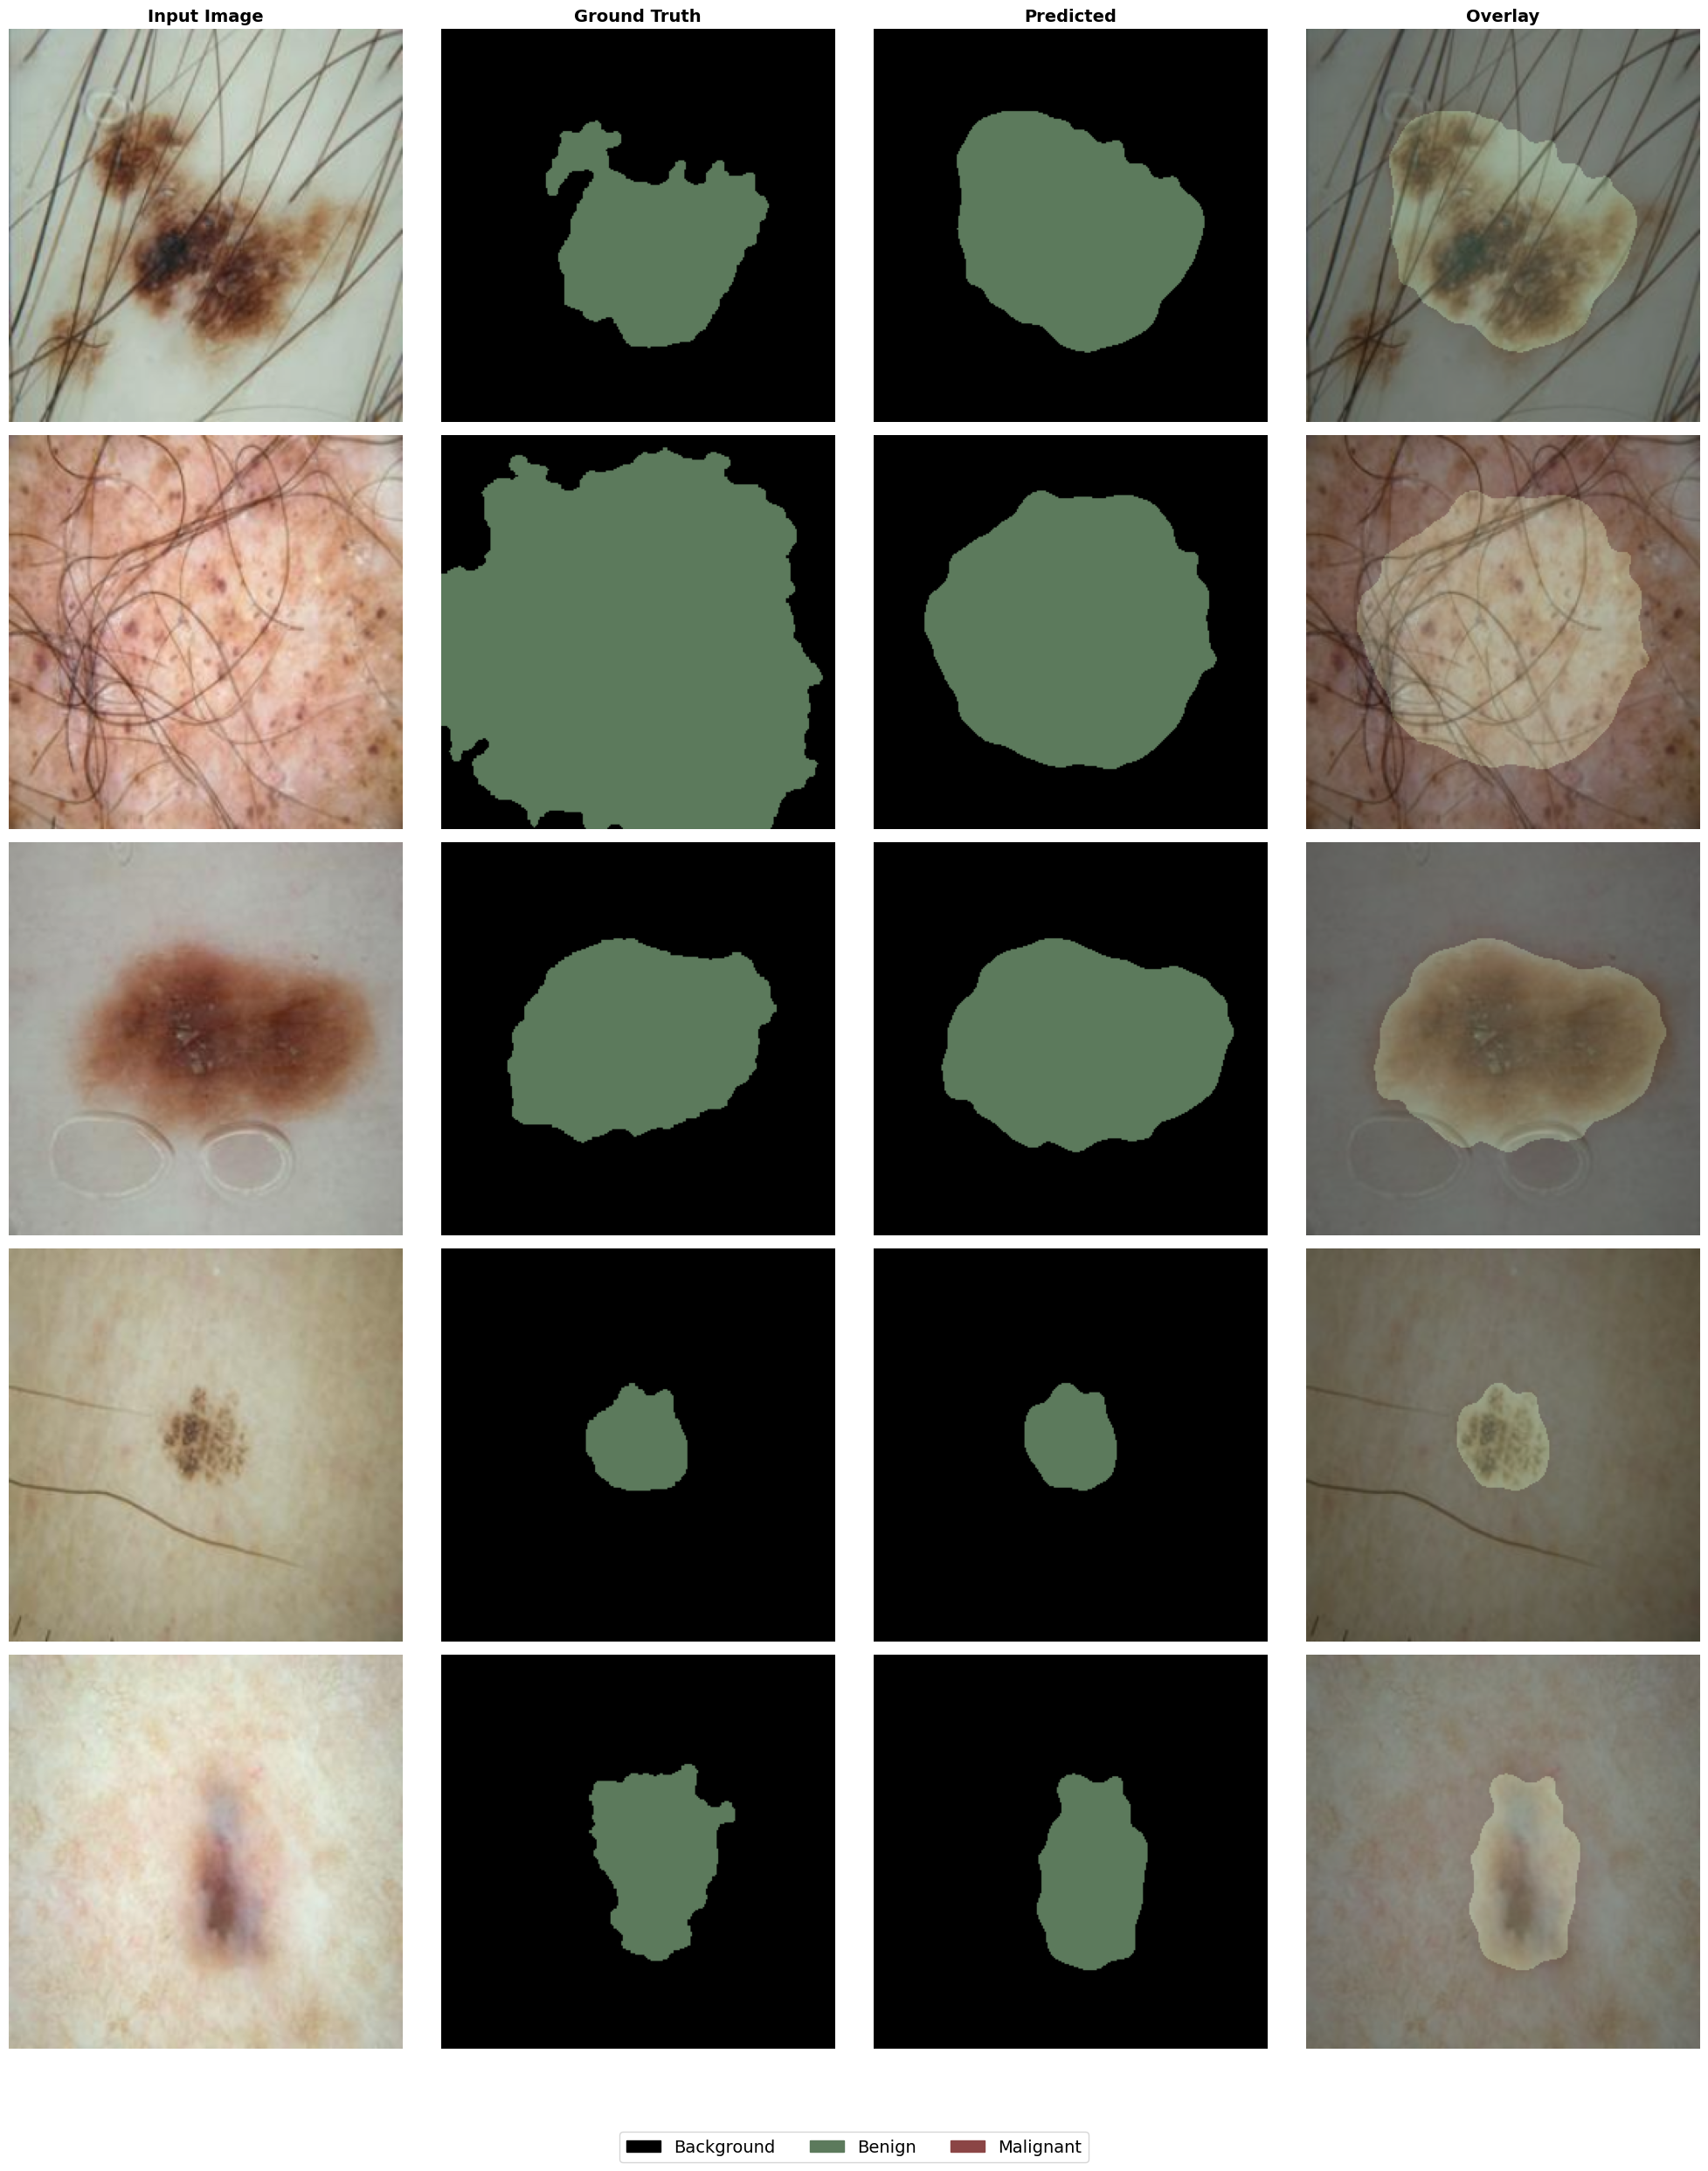

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from collections import defaultdict
import cv2
from transunet_model import build_transunet, DEFAULT_PRETRAINED

# ── Config 
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
IMAGE_DIR   = "/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/test/ISIC_Size_Shortcut_Images"
MASK_DIR    = "/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/test/ISIC_Size_Shortcut_Masks"
ISIC_TEST_CSV = "/home/ahsan/test-project/ISIC-2019/ISIC_Metadata/test_metadata_size_shortcut.csv"
NUM_CLASSES    = 3
BATCH_SIZE     = 8
VIT_NAME = "R50-ViT-B_16"
N_SKIP = 3
IMG_SIZE = 256
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
SEEDS = [22, 42, 123]
DEVICE         = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

# ── FIX 1: INTER_NEAREST for mask to preserve class labels 
def resize_mask_nearest(mask, **kwargs):
    return cv2.resize(mask.astype(np.float32), (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST).astype(np.int32)

def resize_image(image, **kwargs):
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

val_transform = A.Compose([
    A.Lambda(image=resize_image, mask=resize_mask_nearest),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Dataset 
class ISICTestDataset(Dataset):
    def __init__(self, csv_path, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform

        df           = pd.read_csv(csv_path)
        df.columns   = df.columns.str.strip()

        # Strip whitespace from all string columns
        for col in df.select_dtypes(include="object").columns:
            df[col] = df[col].str.strip()

        df["isic_id"] = df["isic_id"].apply(lambda x: os.path.splitext(x)[0])

        self.ids              = df["isic_id"].tolist()
        self.benign_malignant = df["benign_malignant"].astype(str).str.strip().astype(int).tolist()
        self.patches          = df["patches"].astype(str).str.strip().astype(int).tolist()

        print(f"Loaded {len(self.ids)} samples from {csv_path}")
        print(f"  Benign    (bm=0): {self.benign_malignant.count(0)}")
        print(f"  Malignant (bm=1): {self.benign_malignant.count(1)}")
        print(f"  No Patches      : {self.patches.count(0)}")
        print(f"  Patches         : {self.patches.count(1)}")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        isic_id = self.ids[idx]
        bm      = self.benign_malignant[idx]
        patch   = self.patches[idx]

        img_path  = os.path.join(self.image_dir, f"{isic_id}.jpg")
        mask_path = os.path.join(self.mask_dir,  f"{isic_id}_segmentation.png")

        image = np.array(Image.open(img_path).convert("RGB"))           # uint8 HWC
        mask  = np.array(Image.open(mask_path).convert("L"))            # uint8 HW

        # ── FIX 2: use np.int32 not np.int64 for albumentations 
        binary_mask = (mask > 127).astype(np.int32)
        class_label = bm + 1                        # 0→1 benign, 1→2 malignant
        seg_mask    = (binary_mask * class_label).astype(np.int32)

        if self.transform:
            aug   = self.transform(image=image, mask=seg_mask)
            image = aug["image"]                    # [3, H, W] float tensor
            mask  = aug["mask"]                     # [H, W]    int tensor
        else:
            mask  = torch.as_tensor(seg_mask)

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)

        return image, mask.long(), bm, patch


# ── Metrics 
def compute_metrics_2(outputs, masks, num_classes=NUM_CLASSES, smooth=1e-6):
    preds      = outputs.argmax(dim=1)          # [B, H, W]
    acc        = (preds == masks).float().mean().item()

    preds_flat = preds.view(-1)
    masks_flat = masks.view(-1)

    preds_oh   = F.one_hot(preds_flat, num_classes=num_classes).float()  # [N, C]
    masks_oh   = F.one_hot(masks_flat, num_classes=num_classes).float()  # [N, C]

    inter       = (preds_oh * masks_oh).sum(dim=0)    # [C]
    total_preds = preds_oh.sum(dim=0)                 # [C]
    total_masks = masks_oh.sum(dim=0)                 # [C]
    union       = total_preds + total_masks - inter   # [C]

    inter       = inter[1:]
    union       = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)
    if class_present.sum() == 0:
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2.0 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class  = (inter + smooth) / (union + smooth)

    dice_per_class = dice_per_class.clamp(0.0, 1.0)
    iou_per_class  = iou_per_class.clamp(0.0, 1.0)

    return {
        "acc"  : acc,
        "dice" : dice_per_class[class_present].mean().item(),
        "iou"  : iou_per_class[class_present].mean().item(),
    }


def mask_to_rgb(mask_2d):
    if isinstance(mask_2d, torch.Tensor):
        mask_2d = mask_2d.cpu().numpy()
    mask_2d = np.squeeze(mask_2d)
    h, w = mask_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[mask_2d == 0] = [0, 0, 0]
    rgb[mask_2d == 1] = [92, 122, 92]    # benign — matches #5c7a5c
    rgb[mask_2d == 2] = [139, 69, 69]     # malignant — matches #8b4545
    return rgb


SUBGROUPS = [
    "Benign_NoPatches",
    "Benign_Patches",
    "Malignant_NoPatches",
    "Malignant_Patches",
]
SUBGROUP_LABELS = {
    "Benign_NoPatches"    : "Benign_NoPatches",
    "Benign_Patches"      : "Benign_Patches",
    "Malignant_NoPatches" : "Malignant_NoPatches",
    "Malignant_Patches"   : "Malignant_Patches",
}
# Muted palette: sage greens (benign) + dusty reds (malignant)
PLOT_COLOR = {
    "Benign_NoPatches"    : "#D3B683",
    "Benign_Patches"      : "#b5956a",
    "Malignant_NoPatches" : "#D3D3D3",
    "Malignant_Patches"   : "#5c5c5c",
}

SEEDS = [22, 42, 123]
EPOCHS = 50
#CHECKPOINT_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/checkpoints/multiseed"
CHECKPOINT_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/checkpoints/multiseed"
DEFAULT_CHECKPOINT = f"{CHECKPOINT_DIR}/TransUNet_ISIC_multiclass_seed22_epoch{EPOCHS}_size.pth"


def subgroup_key(bm, patch):
    label = "Benign" if bm == 0 else "Malignant"
    patch_label = "Patches" if patch == 1 else "NoPatches"
    return f"{label}_{patch_label}"


def run_sanity_check(model, csv_path, image_dir, mask_dir):
    print("\n── Sanity Check")
    ds = ISICTestDataset(csv_path, image_dir, mask_dir, transform=val_transform)

    all_classes = set()
    for i in range(min(200, len(ds))):
        _, mask, _, _ = ds[i]
        for v in mask.unique().tolist():
            all_classes.add(int(v))
    print(f"Mask classes found (first 200 samples): {sorted(all_classes)}")
    if 2 not in all_classes:
        print("  *** WARNING: class 2 still missing — "
              "check mask_interpolation and seg_mask dtype ***")
    else:
        print("  OK — classes 0, 1, 2 all present")

    loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    images, masks, _, _ = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
    m = compute_metrics_2(outputs, masks)
    print(f"  Sample batch dice: {m['dice']:.4f}  (should be in [0, 1])")
    if m["dice"] < 0 or m["dice"] > 1:
        print("  *** WARNING: dice out of range ***")
    else:
        print("  OK — dice in valid range")


def test_model_subgroups(model, csv_path, image_dir, mask_dir, verbose=True):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
    df["isic_id"] = df["isic_id"].apply(lambda x: os.path.splitext(x)[0])
    df["benign_malignant"] = df["benign_malignant"].astype(str).str.strip().astype(int)
    df["patches"] = df["patches"].astype(str).str.strip().astype(int)

    dice_sum = defaultdict(float)
    iou_sum = defaultdict(float)
    counts = defaultdict(int)

    model.eval()
    for bm in (0, 1):
        for patch in (0, 1):
            key = subgroup_key(bm, patch)
            sub_df = df[(df["benign_malignant"] == bm) & (df["patches"] == patch)]
            if len(sub_df) == 0:
                continue

            sub_ids = set(sub_df["isic_id"].tolist())
            full_ds = ISICTestDataset(csv_path, image_dir, mask_dir, transform=val_transform)
            indices = [i for i, sid in enumerate(full_ds.ids) if sid in sub_ids]
            sub_ds = torch.utils.data.Subset(full_ds, indices)
            loader = DataLoader(sub_ds, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=True)

            with torch.no_grad():
                for images, masks, _, _ in loader:
                    images, masks = images.to(DEVICE), masks.to(DEVICE)
                    outputs = model(images)
                    m = compute_metrics_2(outputs, masks)
                    dice_sum[key] += m["dice"]
                    iou_sum[key] += m["iou"]
                    counts[key] += 1

            if verbose:
                n = counts[key]
                print(f"  {SUBGROUP_LABELS[key]:<22}  "
                      f"Dice={dice_sum[key]/n:.4f}  IoU={iou_sum[key]/n:.4f}")

    results = {}
    for bm in (0, 1):
        for patch in (0, 1):
            key = subgroup_key(bm, patch)
            n_batches = counts[key]
            results[key] = {
                "label": SUBGROUP_LABELS[key],
                "n": len(df[(df["benign_malignant"] == bm) & (df["patches"] == patch)]),
                "dice": dice_sum[key] / n_batches if n_batches > 0 else 0.0,
                "iou":  iou_sum[key]  / n_batches if n_batches > 0 else 0.0,
            }
    return results


def aggregate_multiseed_results(all_results):
    results = {}
    for key in SUBGROUPS:
        seed_results = [r["results"][key] for r in all_results if r["results"][key]["n"] > 0]
        if not seed_results:
            continue
        dice_vals = [sr["dice"] for sr in seed_results]
        iou_vals  = [sr["iou"]  for sr in seed_results]
        results[key] = {
            "label"    : SUBGROUP_LABELS[key],
            "n"        : seed_results[0]["n"],
            "dice"     : float(np.mean(dice_vals)),
            "dice_std" : float(np.std(dice_vals, ddof=1)) if len(dice_vals) > 1 else 0.0,
            "iou"      : float(np.mean(iou_vals)),
            "iou_std"  : float(np.std(iou_vals, ddof=1)) if len(iou_vals) > 1 else 0.0,
        }
    return results


def print_seed_wise_results(all_results):
    print("\n" + "=" * 72)
    print("  ISIC Segmentation — Per-seed Results (Dice / IoU)")
    print("=" * 72)
    for entry in all_results:
        seed = entry["seed"]
        results = entry["results"]
        print(f"\n  Seed {seed}")
        print(f"  {'Subgroup':<22} {'N':>5} {'Dice':>10} {'IoU':>10}")
        print("  " + "-" * 52)
        for key in SUBGROUPS:
            if key not in results or results[key]["n"] == 0:
                continue
            m = results[key]
            print(f"  {m['label']:<22} {m['n']:>5} {m['dice']:>10.4f} {m['iou']:>10.4f}")
    print("=" * 72)


def print_results_table(results):
    print("\n" + "=" * 72)
    print(f"{'Subgroup':<22} {'N':>5} {'Dice':>22} {'IoU':>22}")
    print("=" * 72)
    for key in SUBGROUPS:
        if key not in results:
            continue
        m = results[key]
        if "dice_std" in m:
            print(f"{m['label']:<22} {m['n']:>5} "
                  f"{m['dice']:.4f} ± {m['dice_std']:.4f}   "
                  f"{m['iou']:.4f} ± {m['iou_std']:.4f}")
        else:
            print(f"{m['label']:<22} {m['n']:>5} "
                  f"{m['dice']:>10.4f} {m['iou']:>22.4f}")
    print("=" * 72)


def load_swinunet_checkpoint(ckpt_path):
    model = build_transunet(
    num_classes     = NUM_CLASSES,
    img_size        = IMG_SIZE,
    vit_name        = VIT_NAME,
    n_skip          = N_SKIP,
    pretrained_path = PRETRAINED_PATH,
    device          = DEVICE,)
    model.to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    return model


def evaluate_all_seeds(csv_path, image_dir, mask_dir):
    all_results = []
    for seed in SEEDS:
        ckpt = f"{CHECKPOINT_DIR}/TransUNet_ISIC_multiclass_seed{seed}_epoch{EPOCHS}_size.pth"
        if not os.path.exists(ckpt):
            print(f"Skipping seed {seed}: {ckpt} not found")
            continue
        m = load_swinunet_checkpoint(ckpt)
        print(f"\n{'#'*65}\n  Evaluating seed {seed}\n{'#'*65}")
        run_sanity_check(m, csv_path, image_dir, mask_dir)
        results = test_model_subgroups(m, csv_path, image_dir, mask_dir, verbose=False)
        all_results.append({"seed": seed, "results": results})

    if not all_results:
        return [], {}

    print_seed_wise_results(all_results)
    aggregated = aggregate_multiseed_results(all_results)
    print("\n  ISIC Segmentation — Multi-seed Summary (mean ± std)")
    print_results_table(aggregated)
    return all_results, aggregated


# ── Plotting 
def plot_results(results):
    keys       = [k for k in SUBGROUPS if k in results and results[k]["n"] > 0]
    labels     = [results[k]["label"] for k in keys]
    bar_colors = [PLOT_COLOR[k] for k in keys]
    x          = np.arange(len(keys))

    metrics_cfg = [
        ("dice", "Dice Coefficient"),
        ("iou",  "IoU Score"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(keys) * 2.5), 5))
    fig.suptitle("TransUNet on ISIC Segmentation (Color-Patches shortcut test)",
                 fontsize=20, fontweight='bold')

    for ax, (metric, title) in zip(axes, metrics_cfg):
        values = [results[k][metric] for k in keys]
        stds   = [results[k].get(f"{metric}_std", 0.0) for k in keys]
        bars   = ax.bar(
            x, values, yerr=stds, capsize=4,
            color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5,
            error_kw=dict(elinewidth=1.2, capthick=1.2, ecolor='black'),
        )

        ymax = max((v + s for v, s in zip(values, stds)), default=1.0)
        ax.set_ylim(0, min(1.25, ymax + 0.08))
        label_offset = 0.01

        for bar, val, std in zip(bars, values, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + label_offset,
                f"{val:.3f}",
                ha='center', va='bottom', fontsize=14, fontweight='bold'
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=11)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    legend_handles = [
        mpatches.Patch(
            facecolor=PLOT_COLOR[k], edgecolor='black',
            label=f"{results[k]['label']}  (n={results[k]['n']})"
        )
        for k in keys
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=min(len(keys), 4),
        bbox_to_anchor=(0.5, -0.03),
        fontsize=11, frameon=True
    )
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig("isic_test_id_results.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved → isic_test_id_results.png")


# ── Visualization 
def visualize_predictions(model, csv_path, image_dir, mask_dir, num_examples=5):
    dataset = ISICTestDataset(csv_path, image_dir, mask_dir,
                               transform=val_transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

    model.eval()
    fig, axes     = plt.subplots(num_examples, 4, figsize=(20, 5 * num_examples))
    for col, t in enumerate(["Input Image", "Ground Truth", "Predicted", "Overlay"]):
        axes[0, col].set_title(t, fontsize=14, fontweight='bold')

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    example_count = 0

    with torch.no_grad():
        for images, masks, bm_labels, patch_labels in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(dim=1)

            for i in range(images.size(0)):
                if example_count >= num_examples:
                    break
                img_np  = (images[i].cpu().numpy().transpose(1,2,0) * std + mean).clip(0,1)
                mask_np = masks[i].cpu().numpy().squeeze()
                pred_np = preds[i].cpu().numpy().squeeze()
                label   = "Benign" if bm_labels[i].item() == 0 else "Malignant"
                patch   = "Patches" if patch_labels[i].item() == 1 else "No Patches"
                overlay = (img_np * 0.6 +
                           mask_to_rgb(pred_np).astype(np.float32) / 255 * 0.4).clip(0, 1)

                axes[example_count, 0].imshow(img_np)
                axes[example_count, 0].set_ylabel(f"{label}\n{patch}",
                                                   fontsize=9, fontweight='bold')
                axes[example_count, 0].axis('off')
                axes[example_count, 1].imshow(mask_to_rgb(mask_np))
                axes[example_count, 1].axis('off')
                axes[example_count, 2].imshow(mask_to_rgb(pred_np))
                axes[example_count, 2].axis('off')
                axes[example_count, 3].imshow(overlay)
                axes[example_count, 3].axis('off')
                example_count += 1

            if example_count >= num_examples:
                break

    legend_handles = [
        mpatches.Patch(color='black',           label='Background'),
        mpatches.Patch(color='#5c7a5c',         label='Benign'),
        mpatches.Patch(color='#8b4545',         label='Malignant'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.01), fontsize=14)
    fig.suptitle(" ",
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("isic_viz_id.png", dpi=150, bbox_inches='tight')
    plt.show()

# ── Single checkpoint OR multi-seed evaluation 
USE_MULTISEED = True   # set False to evaluate one checkpoint only
CHECKPOINT_PATH = DEFAULT_CHECKPOINT  # used when USE_MULTISEED is False

model = build_transunet(
    num_classes     = NUM_CLASSES,
    img_size        = IMG_SIZE,
    vit_name        = VIT_NAME,
    n_skip          = N_SKIP,
    pretrained_path = PRETRAINED_PATH,
    device          = DEVICE,
)
model.to(DEVICE)

if USE_MULTISEED:
    multiseed_results, results = evaluate_all_seeds(ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR)
    if multiseed_results:
        plot_results(results)
        ckpt = f"{CHECKPOINT_DIR}/TransUNet_ISIC_multiclass_seed{multiseed_results[0]['seed']}_epoch{EPOCHS}.pth"
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.eval()
        visualize_predictions(model, ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR, num_examples=5)
    else:
        print("No multiseed checkpoints found — train models or set USE_MULTISEED=False.")
else:
    if not os.path.exists(CHECKPOINT_PATH):
        raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
    model = load_swinunet_checkpoint(CHECKPOINT_PATH)
    run_sanity_check(model, ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR)
    results = test_model_subgroups(model, ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR, verbose=False)
    print_results_table(results)
    plot_results(results)
    visualize_predictions(model, ISIC_TEST_CSV, IMAGE_DIR, MASK_DIR, num_examples=5)

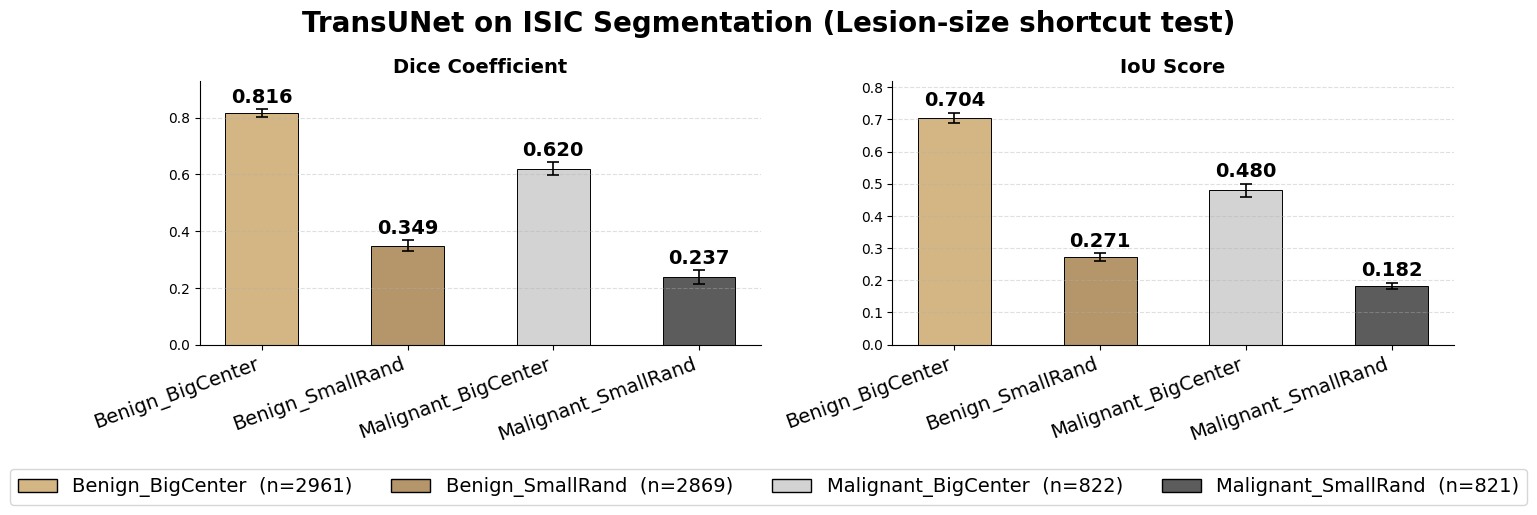

Plot saved → isic_test_id_results.png


In [12]:
# ── Cell: Recreate ISIC Segmentation Bar Plot (manual values) ─────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────
#  EDIT THESE VALUES MANUALLY
# ─────────────────────────────────────────────────────────────
DATA = {
    "benign_no_patch": {
        "label": "Benign_BigCenter",
        "n":     2961,
        "dice":  0.816,  "dice_std": 0.013,
        "iou":   0.704,  "iou_std":  0.015,
        "color": "#D3B683",   # sage green
    },
    "benign_patch": {
        "label": "Benign_SmallRand",
        "n":     2869,
        "dice":  0.349,  "dice_std": 0.018,
        "iou":   0.271,  "iou_std":  0.012,
        "color": "#b5956a",   # dark green
    },
    "malignant_no_patch": {
        "label": "Malignant_BigCenter",
        "n":     822,
        "dice":  0.620,  "dice_std": 0.022,
        "iou":   0.480,  "iou_std":  0.020,
        "color": "#D3D3D3",   # dusty rose
    },
    "malignant_patch": {
        "label": "Malignant_SmallRand",
        "n":     821,
        "dice":  0.237,  "dice_std": 0.025,
        "iou":   0.182,  "iou_std":  0.010,
        "color": "#5c5c5c",   # dark red
    },
}

METRICS = [
    ("dice", "dice_std", "Dice Coefficient"),
    ("iou",  "iou_std",  "IoU Score"),
]

# ─────────────────────────────────────────────────────────────
#  PLOT
# ─────────────────────────────────────────────────────────────
keys   = list(DATA.keys())
labels = [DATA[k]["label"] for k in keys]
x      = np.arange(len(keys))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "TransUNet on ISIC Segmentation (Lesion-size shortcut test)",
    fontsize=20, fontweight="bold"
)

for ax, (metric, std_key, title) in zip(axes, METRICS):
    values = [DATA[k][metric]   for k in keys]
    stds   = [DATA[k][std_key]  for k in keys]
    colors = [DATA[k]["color"]  for k in keys]

    bars = ax.bar(
        x, values,
        yerr=stds, capsize=4,
        color=colors, edgecolor="black", linewidth=0.7, width=0.5,
        error_kw=dict(elinewidth=1.2, capthick=1.2, ecolor="black"),
    )

    ymax = max(v + s for v, s in zip(values, stds))
    ax.set_ylim(0, min(1.0, ymax + 0.10))

    label_offset = 0.01
    for bar, val, std in zip(bars, values, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + label_offset,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=14, fontweight="bold"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=14)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(
        facecolor=DATA[k]["color"], edgecolor="black",
        label=f"{DATA[k]['label']}  (n={DATA[k]['n']})"
    )
    for k in keys
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(keys),
    bbox_to_anchor=(0.5, -0.03),
    fontsize=14, frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("isic_test_id_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → isic_test_id_results.png")

In [ ]:
ISIC Segmentation — Multi-seed Summary (mean ± std) with patches
========================================================================
Subgroup                   N       Dice             IoU
========================================================================
Benign/No Patches       2961 0.8264 ± 0.0063   0.7162 ± 0.0091
Benign/Patches          2869 0.6203 ± 0.0077   0.4698 ± 0.0067
Malignant/No Patches     822 0.6703 ± 0.0168   0.5362 ± 0.0180
Malignant/Patches        821 0.5002 ± 0.0193   0.3762 ± 0.0191
=================================================================
Subgroup                   N     Dice              IoU     size-shortcut
========================================================================
Benign/No Patches       2961 0.8213 ± 0.0033   0.7089 ± 0.0051
Benign/Patches          2869 0.0763 ± 0.0044   0.0509 ± 0.0021
Malignant/No Patches     822 0.6923 ± 0.0074   0.5588 ± 0.0088
Malignant/Patches        821 0.2849 ± 0.0196   0.1913 ± 0.0184

In [ ]:
"""==============================Patches 100 epochs=================="""
Subgroup                      N   Accuracy     Dice      IoU     Loss
=================================================================
Benign_NoPatches           3158     0.9295   0.8191   0.7428   0.0740
Benign_Patches             2763     0.9754   0.5116   0.4230   0.1566
Malignant_NoPatches         822     0.8381   0.4663   0.4159   0.1986
Malignant_Patches           821     0.8382   0.3669   0.3132   0.2310
=================================================================
"""==============================Patches 100 epochs=================="""
Subgroup                      N   Accuracy     Dice      IoU     Loss
=================================================================
Benign_NoPatches           3158     0.9075   0.7457   0.6713   0.0997
Benign_Patches             2763     0.9740   0.5294   0.4335   0.1510
Malignant_NoPatches         822     0.8655   0.5930   0.5230   0.1577
Malignant_Patches           821     0.8594   0.5005   0.4239   0.1887
=================================================================
"""==============================Patches 50 epochs==================="""
=====================================================================
Subgroup                      N   Accuracy     Dice      IoU     Loss
=====================================================================
Benign_NoPatches           3158     0.9161   0.7843   0.7033   0.0878   
Benign_Patches             2763     0.9735   0.4901   0.3997   0.1653
Malignant_NoPatches         822     0.8567   0.5318   0.4710   0.1772
Malignant_Patches           821     0.8603   0.4593   0.3923   0.2009
"""=============================Size 30%=============================""" perform again 
=====================================================================
Subgroup                      N   Accuracy     Dice      IoU     Loss
=====================================================================
Benign_NoPatches           3158     0.9159   0.7858   0.7036   0.0878
Benign_Patches             2763     0.9730   0.4907   0.3975   0.1657
Malignant_NoPatches         822     0.8510   0.4961   0.4400   0.1898
Malignant_Patches           821     0.8604   0.4406   0.3754   0.2070
=================================================================   

In [ ]:
""" without shortcuts """
Subgroup                      N   Accuracy     Dice      IoU     Loss
=================================================================
Benign_NoPatches           3158     0.9323   0.8239   0.7480   0.0725
Benign_Patches             2763     0.9592   0.4701   0.3768   0.1737
Malignant_NoPatches         822     0.8406   0.4688   0.4182   0.1977
Malignant_Patches           821     0.8447   0.4320   0.3676   0.2103
""" without shortcuts """
=====================================================================
Subgroup                      N   Accuracy     Dice      IoU     Loss
=================================================================
Benign_NoPatches           3158     0.9125   0.7785   0.6960   0.0906
Benign_Patches                0     0.0000   0.0000   0.0000   0.0000
Malignant_NoPatches         822     0.8594   0.5554   0.4907   0.1698
Malignant_Patches             0     0.0000   0.0000   0.0000   0.0000
""" without shortcuts - OOD """
Subgroup                      N   Accuracy     Dice      IoU     Loss
=================================================================
Benign_NoPatches           3158     0.9125   0.7785   0.6960   0.0906
Benign_Patches             2763     0.9407   0.4347   0.3379   0.1915
Malignant_NoPatches         822     0.8594   0.5554   0.4907   0.1698
Malignant_Patches           821     0.8582   0.5232   0.4434   0.1824